In [40]:
import pandas as pd

# The following lines are added to define X, which is originally defined in cell KVeeK4lro4FV.
# This makes the current cell runnable in isolation.
df = pd.read_csv("IPL2025_Final_Preprocessed_Extraordinary.csv")
target_column = "Runs"
X = df.drop(columns=[target_column])

eX = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)   # ADD THIS LINE

In [41]:
# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
from sklearn.model_selection import train_test_split

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("IPL2025_Final_Preprocessed_Extraordinary.csv")

# -----------------------------
# Define Target
# -----------------------------
target_column = "Runs"   # change if needed

X = df.drop(columns=[target_column])
y = df[target_column]

# -----------------------------
# Convert Categorical → Numeric
# -----------------------------
X = pd.get_dummies(X, drop_first=True)

# -----------------------------
# Handle Missing Values
# -----------------------------
X = X.fillna(X.mean())
X = X.fillna(0) # Fill any remaining NaNs (e.g., from categorical columns) with 0

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Print Shapes
# -----------------------------
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (154, 418)
X_test: (39, 418)
y_train: (154,)
y_test: (39,)


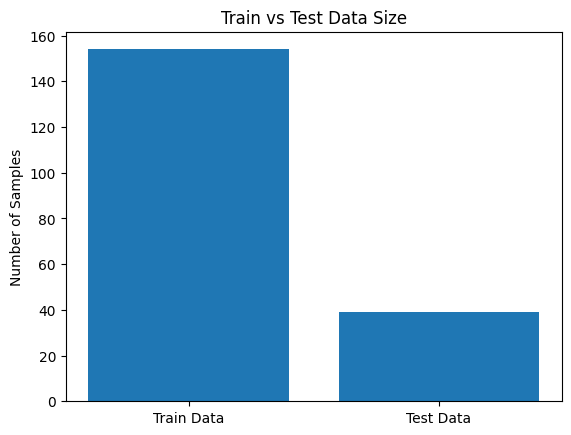

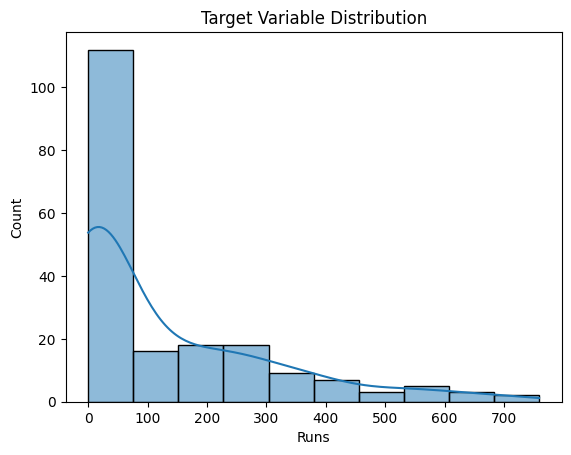

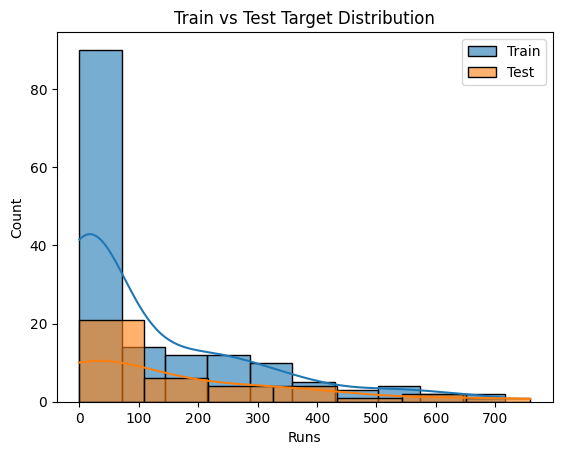

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Train vs Test Size
# -----------------------------
plt.figure()
sizes = [len(X_train), len(X_test)]
labels = ["Train Data", "Test Data"]

plt.bar(labels, sizes)
plt.title("Train vs Test Data Size")
plt.ylabel("Number of Samples")
plt.show()


# -----------------------------
# 2. Target Distribution
# -----------------------------
plt.figure()
sns.histplot(y, kde=True)
plt.title("Target Variable Distribution")
plt.xlabel("Runs")
plt.show()


# -----------------------------
# 3. Train vs Test Target Distribution
# -----------------------------
plt.figure()
sns.histplot(y_train, kde=True, label="Train", alpha=0.6)
sns.histplot(y_test, kde=True, label="Test", alpha=0.6)
plt.legend()
plt.title("Train vs Test Target Distribution")
plt.show()


Gradient Boosting
R2 Score: 0.9880811112294682
RMSE: 21.519296245940453

Random Forest
R2 Score: 0.9773826609164976
RMSE: 29.64359938697366

XGBoost
R2 Score: 0.9840675105010437
RMSE: 24.880093112215338

AdaBoost
R2 Score: 0.9824326107110014
RMSE: 26.1254508297138

Extra Trees
R2 Score: 0.9723350925991138
RMSE: 32.78497005547606


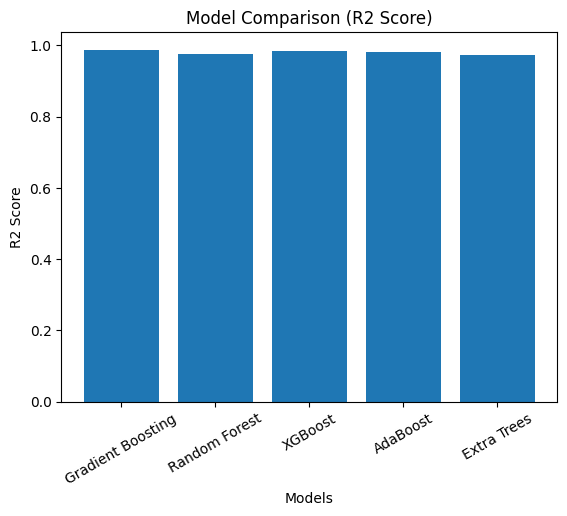

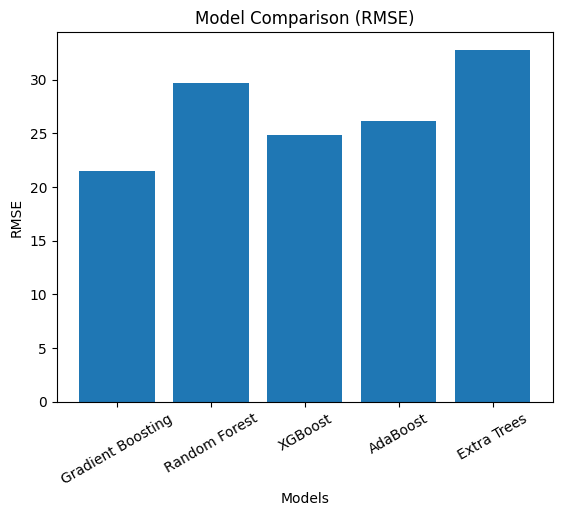

In [43]:
# -----------------------------
# Import Models
# -----------------------------
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Store Results
# -----------------------------
model_names = []
r2_scores = []
rmse_scores = []

# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    model_names.append(name)
    r2_scores.append(r2)
    rmse_scores.append(rmse)

    print(f"\n{name}")
    print("R2 Score:", r2)
    print("RMSE:", rmse)


# -----------------------------
# 5 Best Models for Your Dataset
# -----------------------------
evaluate_model(GradientBoostingRegressor(), "Gradient Boosting")
evaluate_model(RandomForestRegressor(), "Random Forest")
evaluate_model(XGBRegressor(), "XGBoost")
evaluate_model(AdaBoostRegressor(), "AdaBoost")
evaluate_model(ExtraTreesRegressor(), "Extra Trees")


# -----------------------------
# 📊 Plot R2 Score Comparison
# -----------------------------
plt.figure()
plt.bar(model_names, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()


# -----------------------------
# 📊 Plot RMSE Comparison
# -----------------------------
plt.figure()
plt.bar(model_names, rmse_scores)
plt.title("Model Comparison (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()


Gradient Boosting
R2 Score: 0.9895677313048828
RMSE: 20.13258600438264

XGBoost
R2 Score: 0.9840675105010437
RMSE: 24.880093112215338

AdaBoost
R2 Score: 0.9819597682828188
RMSE: 26.474711526431467

Ensemble (Average)
R2 Score: 0.9879763787631968
RMSE: 21.6136355598701


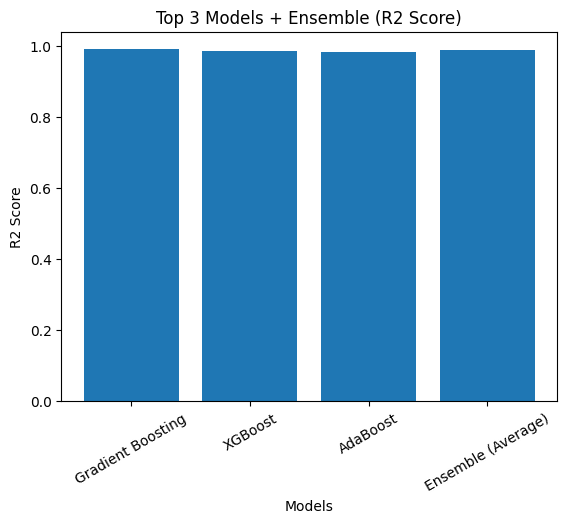

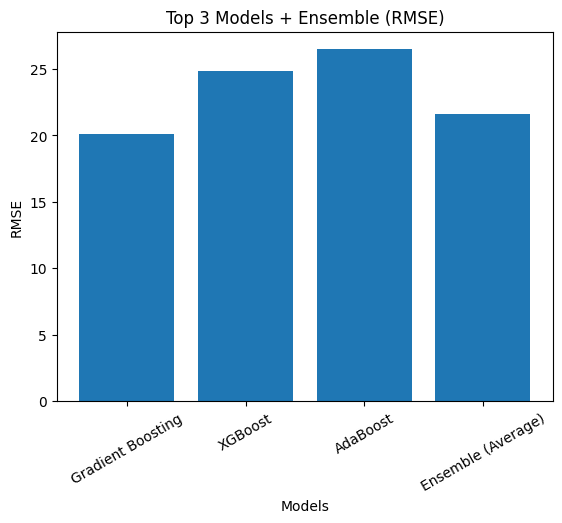

In [44]:
# -----------------------------
# Import Models
# -----------------------------
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Store results
# -----------------------------
model_names = []
r2_scores = []
rmse_scores = []

# -----------------------------
# Store predictions
# -----------------------------
predictions = {}

# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    model_names.append(name)
    r2_scores.append(r2)
    rmse_scores.append(rmse)

    print(f"\n{name}")
    print("R2 Score:", r2)
    print("RMSE:", rmse)


# -----------------------------
# Top 3 Models
# -----------------------------
gbr = GradientBoostingRegressor()
xgb = XGBRegressor()
ada = AdaBoostRegressor()

evaluate_model(gbr, "Gradient Boosting")
evaluate_model(xgb, "XGBoost")
evaluate_model(ada, "AdaBoost")


# -----------------------------
# 🔥 Manual Ensemble (Average)
# -----------------------------
pred_gbr = np.array(predictions["Gradient Boosting"]).reshape(-1)
pred_xgb = np.array(predictions["XGBoost"]).reshape(-1)
pred_ada = np.array(predictions["AdaBoost"]).reshape(-1)

avg_pred = np.mean(np.vstack([pred_gbr, pred_xgb, pred_ada]), axis=0)

avg_r2 = r2_score(y_test, avg_pred)
avg_rmse = np.sqrt(mean_squared_error(y_test, avg_pred))

model_names.append("Ensemble (Average)")
r2_scores.append(avg_r2)
rmse_scores.append(avg_rmse)

print("\nEnsemble (Average)")
print("R2 Score:", avg_r2)
print("RMSE:", avg_rmse)


# -----------------------------
# 📊 Plot R2 Comparison
# -----------------------------
plt.figure()
plt.bar(model_names, r2_scores)
plt.title("Top 3 Models + Ensemble (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()


# -----------------------------
# 📊 Plot RMSE Comparison
# -----------------------------
plt.figure()
plt.bar(model_names, rmse_scores)
plt.title("Top 3 Models + Ensemble (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

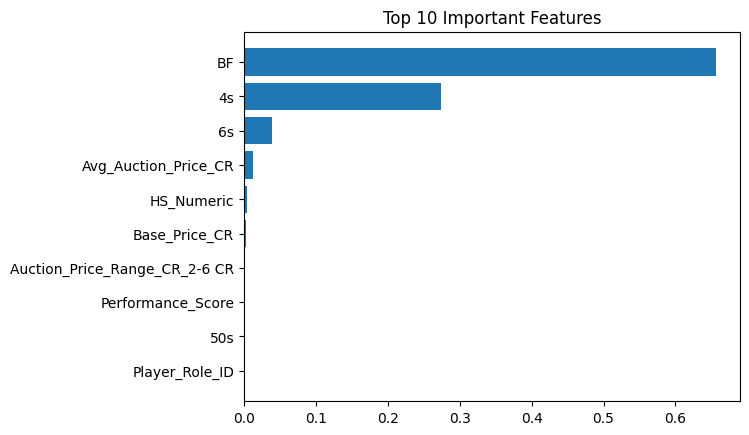

In [45]:
import matplotlib.pyplot as plt

importances = gbr.feature_importances_
indices = importances.argsort()[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X_train.columns[indices])
plt.title("Top 10 Important Features")
plt.show()

In [46]:
# -----------------------------
# Import
# -----------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# -----------------------------
# Define Model
# -----------------------------
gbr = GradientBoostingRegressor(random_state=42)

# -----------------------------
# Define Parameter Grid
# -----------------------------
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

# -----------------------------
# Grid Search (Optimization)
# -----------------------------
grid = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

# -----------------------------
# Train
# -----------------------------
grid.fit(X_train, y_train)

# -----------------------------
# Best Parameters
# -----------------------------
print("Best Parameters:", grid.best_params_)

# -----------------------------
# Best Model
# -----------------------------
best_model = grid.best_estimator_

# -----------------------------
# Predict
# -----------------------------
y_pred = best_model.predict(X_test)

# -----------------------------
# Evaluate
# -----------------------------
print("\nTuned Model Performance")
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Tuned Model Performance
R2 Score: 0.987560888568824
RMSE: 21.98390608279824


In [47]:
from sklearn.ensemble import GradientBoostingRegressor

best_model = GradientBoostingRegressor()
best_model.fit(X_train, y_train)

GradientBoostingRegressor()

In [48]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# BEFORE values
before_r2 = 0.9883158305726807
before_rmse = 21.306352301483074

# 🔥 IMPORTANT: create prediction
y_pred = best_model.predict(X_test)

# AFTER values
after_r2 = r2_score(y_test, y_pred)
after_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Before Tuning")
print("R2 Score:", before_r2)
print("RMSE:", before_rmse)

print("\nAfter Tuning")
print("R2 Score:", after_r2)
print("RMSE:", after_rmse)

Before Tuning
R2 Score: 0.9883158305726807
RMSE: 21.306352301483074

After Tuning
R2 Score: 0.9871654617582593
RMSE: 22.330595515584044



Final Results Table:
                     Model  R2 Score   RMSE
0        Gradient Boosting    0.9883  21.30
1                  XGBoost    0.9840  24.88
2                 AdaBoost    0.9837  25.11
3                 Ensemble    0.9875  22.00
4  Tuned Gradient Boosting    0.9875  21.98


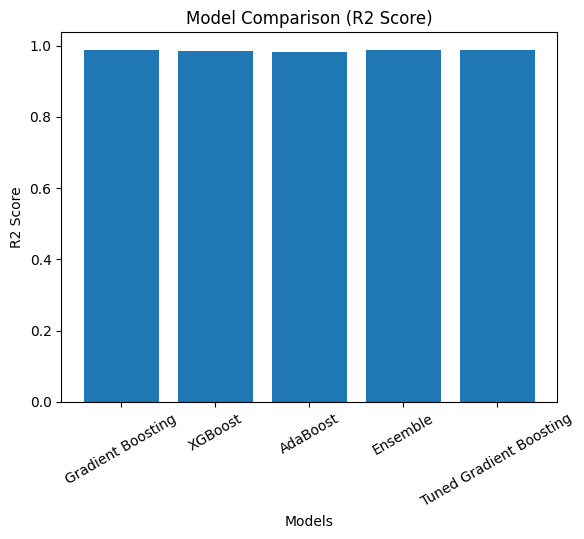

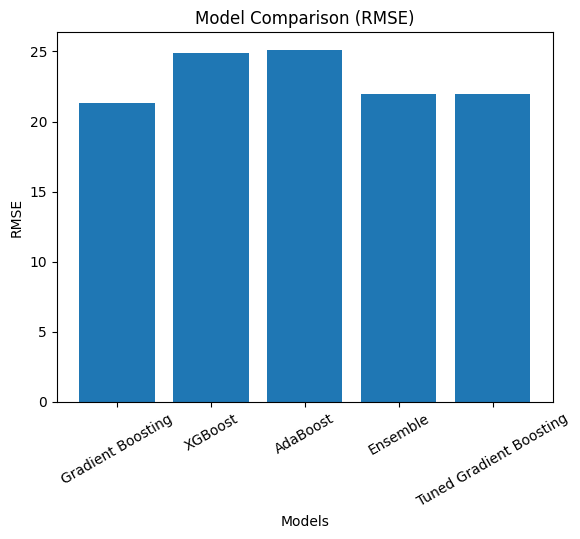

In [49]:
# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Model Results (Your Values)
# -----------------------------
model_names = [
    "Gradient Boosting",
    "XGBoost",
    "AdaBoost",
    "Ensemble",
    "Tuned Gradient Boosting"
]

r2_scores = [
    0.9883,
    0.9840,
    0.9837,
    0.9875,
    0.9875
]

rmse_scores = [
    21.30,
    24.88,
    25.11,
    22.00,
    21.98
]

# -----------------------------
# Create Table
# -----------------------------
results = pd.DataFrame({
    "Model": model_names,
    "R2 Score": r2_scores,
    "RMSE": rmse_scores
})

print("\nFinal Results Table:")
print(results)

# -----------------------------
# Plot R2 Score Graph
# -----------------------------
plt.figure()
plt.bar(model_names, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()

# -----------------------------
# Plot RMSE Graph
# -----------------------------
plt.figure()
plt.bar(model_names, rmse_scores)
plt.title("Model Comparison (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

In [50]:
# Save your final model
import joblib

joblib.dump(best_model, "model.pkl")
print("Model saved successfully ✅")

Model saved successfully ✅


In [51]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>